In [1]:

import os
from pathlib import Path
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp")
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

# Print-friendly plotting helpers for black-and-white Xerox copies.
PRINT_HATCHES = ["", "///", "\\\\", "xx", "..", "++", "--", "oo", "**", "OO"]
PRINT_MARKERS = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
PRINT_GRAYS = ["#111111", "#444444", "#777777", "#AAAAAA", "#DDDDDD"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#111111",
    "axes.labelcolor": "#111111",
    "xtick.color": "#111111",
    "ytick.color": "#111111",
    "grid.color": "#D0D0D0",
})

def print_palette(n):
    if n <= 0:
        return []
    return [PRINT_GRAYS[i % len(PRINT_GRAYS)] for i in range(n)]

def apply_bar_hatches(ax, hatches=PRINT_HATCHES):
    for i, patch in enumerate(ax.patches):
        patch.set_facecolor("white")
        patch.set_edgecolor("#111111")
        patch.set_linewidth(1.0)
        patch.set_hatch(hatches[i % len(hatches)])
    return ax

def boxplot_print(data, x, y, ax=None, showfliers=False):
    ax = ax or plt.gca()
    sns.boxplot(
        data=data,
        x=x,
        y=y,
        ax=ax,
        color="white",
        showfliers=showfliers,
        boxprops={"facecolor": "white", "edgecolor": "#111111", "linewidth": 1.0},
        medianprops={"color": "#111111", "linewidth": 1.3},
        whiskerprops={"color": "#111111", "linewidth": 1.0},
        capprops={"color": "#111111", "linewidth": 1.0},
    )
    for i, patch in enumerate(ax.patches):
        patch.set_hatch(PRINT_HATCHES[i % len(PRINT_HATCHES)])
        patch.set_edgecolor("#111111")
    return ax

def scatter_with_markers(data, x, y, hue, title, xlabel=None, ylabel=None, max_legend_items=12):
    fig, ax = plt.subplots(figsize=(8.5, 6))
    labels = data[hue].astype("string").fillna("<NA>")
    order = labels.value_counts().index.tolist()
    if len(order) > max_legend_items:
        keep = set(order[:max_legend_items - 1])
        plot_data = data.copy()
        plot_data[hue] = labels.where(labels.isin(keep), "Other")
        labels = plot_data[hue].astype("string")
        order = labels.value_counts().index.tolist()
    else:
        plot_data = data.copy()
        plot_data[hue] = labels

    for i, label in enumerate(order):
        subset = plot_data[plot_data[hue].astype("string") == str(label)]
        ax.scatter(
            subset[x],
            subset[y],
            marker=PRINT_MARKERS[i % len(PRINT_MARKERS)],
            facecolors="none",
            edgecolors="#111111",
            linewidths=0.75,
            alpha=0.7,
            s=24,
            label=str(label),
        )
    ax.set_title(title)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)
    ax.legend(title=hue, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    return ax


RANDOM_STATE = 42
PLOT_SAMPLE_SIZE = 50_000

def find_data_file(filename):
    candidates = [
        Path(filename),
        Path("eda") / filename,
        Path("..") / "eda" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename}. Tried: {candidates}")

def display_basic_profile(df, target_col=None):
    memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    profile = pd.DataFrame({
        "metric": ["rows", "columns", "memory_mb", "duplicate_rows", "total_missing_cells"],
        "value": [len(df), df.shape[1], round(memory_mb, 2), int(df.duplicated().sum()), int(df.isna().sum().sum())],
    })
    display(profile)
    if target_col and target_col in df.columns:
        target_summary = (
            df[target_col]
            .value_counts(dropna=False)
            .rename_axis(target_col)
            .reset_index(name="count")
        )
        target_summary["percent"] = (target_summary["count"] / len(df) * 100).round(2)
        display(target_summary)

def get_numeric_columns(df, exclude=None):
    exclude = set(exclude or [])
    return [c for c in df.select_dtypes(include=np.number).columns if c not in exclude]

def get_categorical_columns(df, exclude=None):
    exclude = set(exclude or [])
    return [c for c in df.select_dtypes(include=["object", "string", "category", "bool"]).columns if c not in exclude]

def sampled(df, n=PLOT_SAMPLE_SIZE):
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=RANDOM_STATE)

def plot_target_distribution(df, target_col, title):
    order = df[target_col].value_counts(dropna=False).index
    plt.figure(figsize=(8, 4.5))
    ax = sns.countplot(data=df, x=target_col, order=order, color="white", edgecolor="#111111")
    apply_bar_hatches(ax)
    ax.set_title(title)
    ax.set_xlabel(target_col)
    ax.set_ylabel("Rows")
    ax.tick_params(axis="x", rotation=30)
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", fontsize=9)
    plt.tight_layout()
    plt.show()

def plot_missing_values(df):
    missing = df.isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0].head(20)
    if missing.empty:
        display(Markdown("No missing values after loading and standard cleanup."))
        return
    plt.figure(figsize=(10, max(3, len(missing) * 0.3)))
    ax = sns.barplot(x=missing.values, y=missing.index, color="white", edgecolor="#111111")
    apply_bar_hatches(ax)
    plt.title("Top columns by missing value count")
    plt.xlabel("Missing cells")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

def plot_numeric_distributions(df, columns, title):
    if not columns:
        display(Markdown("No numeric columns available for distribution plots."))
        return
    sample = sampled(df)
    n_cols = min(3, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, columns):
        values = pd.to_numeric(sample[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        if values.empty:
            ax.set_visible(False)
            continue
        label = col
        if values.min() >= 0 and values.quantile(0.99) > max(values.median() * 10, 10):
            values = np.log1p(values)
            label = f"log1p({col})"
        sns.histplot(values, bins=40, kde=True, ax=ax, color="#D9D9D9", edgecolor="#111111", line_kws={"color": "#111111"})
        ax.set_title(col)
        ax.set_xlabel(label)
    for ax in axes[len(columns):]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_categorical_top_counts(df, columns, title):
    if not columns:
        display(Markdown("No categorical columns available for count plots."))
        return
    n_cols = min(2, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, columns):
        counts = df[col].astype("string").fillna("<NA>").value_counts().head(12)
        sns.barplot(x=counts.values, y=counts.index, ax=ax, color="white", edgecolor="#111111")
        apply_bar_hatches(ax)
        ax.set_title(col)
        ax.set_xlabel("Rows")
        ax.set_ylabel("")
    for ax in axes[len(columns):]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

def target_association(df, target_col, numeric_cols, exclude=None):
    exclude = set(exclude or []) | {target_col}
    numeric_cols = [c for c in numeric_cols if c not in exclude]
    if target_col not in df.columns or not numeric_cols:
        return pd.Series(dtype="float64")
    y = pd.Series(pd.factorize(df[target_col].astype("string"))[0], index=df.index)
    values = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    corr = values.corrwith(y).abs().sort_values(ascending=False)
    return corr.dropna()

def plot_correlation_heatmap(df, numeric_cols, title, max_features=18):
    numeric_cols = list(numeric_cols)[:max_features]
    if len(numeric_cols) < 2:
        display(Markdown("Not enough numeric columns for a correlation heatmap."))
        return
    corr = df[numeric_cols].replace([np.inf, -np.inf], np.nan).corr()
    plt.figure(figsize=(12, 9))
    sns.heatmap(corr, cmap="Greys", center=0, linewidths=0.3, square=False, linecolor="#CCCCCC")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_numeric_by_target(df, target_col, columns, title):
    if not columns:
        display(Markdown("No numeric columns selected for target comparison."))
        return
    sample = sampled(df, 30_000)
    n_cols = min(3, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, columns):
        values = sample[[target_col, col]].copy()
        values[col] = pd.to_numeric(values[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
        values = values.dropna(subset=[col])
        if values.empty:
            ax.set_visible(False)
            continue
        if values[col].min() >= 0 and values[col].quantile(0.99) > max(values[col].median() * 10, 10):
            values[col] = np.log1p(values[col])
            ylabel = f"log1p({col})"
        else:
            ylabel = col
        boxplot_print(values, target_col, col, ax=ax, showfliers=False)
        ax.set_title(col)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=25)
    for ax in axes[len(columns):]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


## Load Data

In [2]:

DATA_PATH = find_data_file("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
raw_df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

# CICIDS headers contain leading spaces. Strip them so feature names are easier to use.
df = raw_df.copy()
df.columns = df.columns.str.strip()

numeric_cols_raw = df.select_dtypes(include=np.number).columns
inf_count = int(np.isinf(df[numeric_cols_raw].to_numpy()).sum())
print(f"Loaded from: {DATA_PATH}")
print(f"Infinite numeric values before cleanup: {inf_count}")

df[numeric_cols_raw] = df[numeric_cols_raw].replace([np.inf, -np.inf], np.nan)


Loaded from: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Infinite numeric values before cleanup: 64


In [3]:
TARGET_COL = 'Label'
EXCLUDE_COLS = ['Label']
PREFERRED_NUMERIC = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean', 'Average Packet Size', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward']
PREFERRED_CATEGORICAL = ['Label']

display_basic_profile(df, TARGET_COL)
display(df.head())

,metric,value
0,rows,"225,745.0000"
1,columns,79.0000
2,memory_mb,145.9400
3,duplicate_rows,"2,633.0000"
4,total_missing_cells,68.0000


,Label,count,percent
0,DDoS,128027,56.7100
1,BENIGN,97718,43.2900


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,"4,000,000.0000","666,666.6667",3.0000,0.0000,3,3,3,3.0000,0.0000,3,3,0,0.0000,0.0000,0,0,0,0,0,0,40,0,"666,666.6667",0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,0,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0000,0.0000,6,6,6.0000,0.0000,"110,091.7431","18,348.6238",109.0000,0.0000,109,109,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,20,20,"9,174.3119","9,174.3119",6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,1,9.0000,6.0000,6.0000,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0000,0.0000,6,6,6.0000,0.0000,"230,769.2308","38,461.5385",52.0000,0.0000,52,52,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,20,20,"19,230.7692","19,230.7692",6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,1,9.0000,6.0000,6.0000,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0000,0.0000,6,6,6.0000,0.0000,"352,941.1765","58,823.5294",34.0000,0.0000,34,34,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,20,20,"29,411.7647","29,411.7647",6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,1,9.0000,6.0000,6.0000,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,"4,000,000.0000","666,666.6667",3.0000,0.0000,3,3,3,3.0000,0.0000,3,3,0,0.0000,0.0000,0,0,0,0,0,0,40,0,"666,666.6667",0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,0,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN


## Data Quality

,dtype,non_null,missing,unique
Flow Bytes/s,float64,225711,34,202293
Flow Packets/s,float64,225711,34,194094
Flow IAT Mean,float64,225745,0,193666
Fwd Packets/s,float64,225745,0,192230
Flow Duration,int64,225745,0,187752
Flow IAT Std,float64,225745,0,159622
Bwd Packets/s,float64,225745,0,144444
Flow IAT Max,int64,225745,0,139745
Bwd IAT Mean,float64,225745,0,117311
Bwd IAT Std,float64,225745,0,113859


,missing_count,missing_percent
Flow Bytes/s,34,0.0150
Flow Packets/s,34,0.0150
Flow Duration,0,0.0000
Total Backward Packets,0,0.0000
Total Length of Fwd Packets,0,0.0000
Total Length of Bwd Packets,0,0.0000
Destination Port,0,0.0000
Fwd Packet Length Max,0,0.0000
Fwd Packet Length Min,0,0.0000
Fwd Packet Length Std,0,0.0000


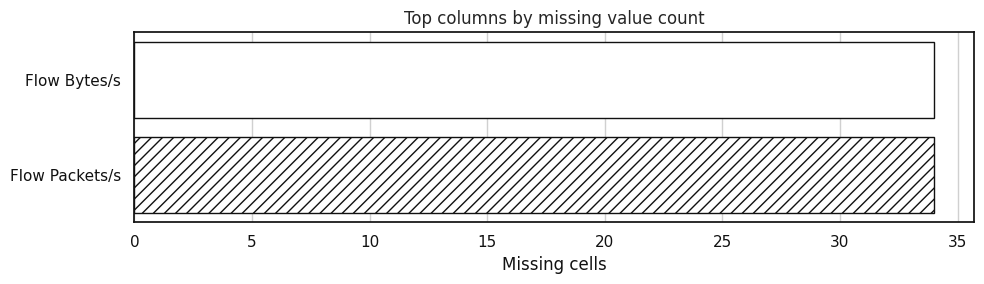

In [4]:

# Data quality checks
missing = (
    df.isna().sum()
    .rename("missing_count")
    .to_frame()
)
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(3)
missing = missing.sort_values("missing_count", ascending=False)

dtype_summary = (
    pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "unique": df.nunique(dropna=False),
    })
    .sort_values(["missing", "unique"], ascending=[False, False])
)

display(dtype_summary.head(30))
display(missing.head(20))
plot_missing_values(df)


## Target Distribution

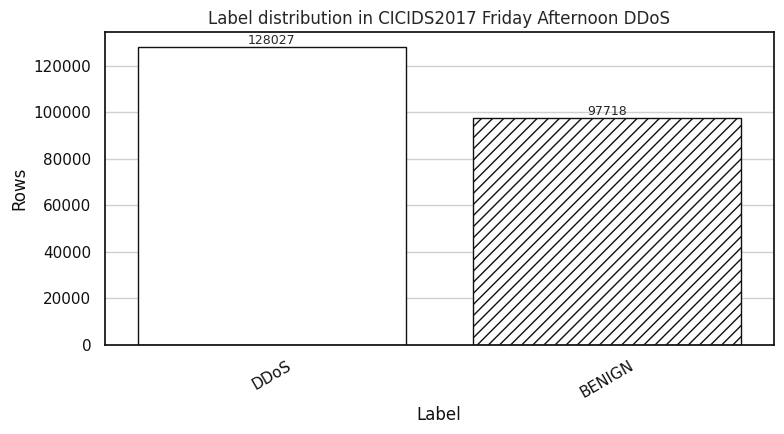

In [5]:
plot_target_distribution(df, TARGET_COL, f"{TARGET_COL} distribution in CICIDS2017 Friday Afternoon DDoS")

## Feature Summaries

In [6]:

# Numeric and categorical summaries
numeric_cols = get_numeric_columns(df, exclude=EXCLUDE_COLS)
categorical_cols = get_categorical_columns(df, exclude=EXCLUDE_COLS)

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

display(df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T if numeric_cols else pd.DataFrame())

categorical_profile = pd.DataFrame({
    "column": categorical_cols,
    "unique_values": [df[c].nunique(dropna=False) for c in categorical_cols],
    "top_value": [df[c].astype("string").fillna("<NA>").mode().iloc[0] if not df[c].mode(dropna=False).empty else None for c in categorical_cols],
    "top_count": [df[c].astype("string").fillna("<NA>").value_counts().iloc[0] if len(df) else 0 for c in categorical_cols],
})
display(categorical_profile.sort_values("unique_values", ascending=False))


Numeric columns: 78
Categorical columns: 0


,count,mean,std,min,1%,5%,50%,95%,99%,max
Destination Port,"225,745.0000","8,879.6195","19,754.6474",0.0000,53.0000,53.0000,80.0000,"58,731.8000","63,808.5600","65,532.0000"
Flow Duration,"225,745.0000","16,241,648.5281","31,524,374.2319",-1.0000,4.0000,161.0000,"1,452,333.0000","93,204,499.8000","115,860,163.7600","119,999,937.0000"
Total Fwd Packets,"225,745.0000",4.8749,15.4229,1.0000,1.0000,1.0000,3.0000,9.0000,27.0000,"1,932.0000"
Total Backward Packets,"225,745.0000",4.5728,21.7554,0.0000,0.0000,0.0000,4.0000,9.0000,29.0000,"2,942.0000"
Total Length of Fwd Packets,"225,745.0000",939.4633,"3,249.4035",0.0000,0.0000,6.0000,30.0000,"11,607.0000","11,613.0000","183,012.0000"
Total Length of Bwd Packets,"225,745.0000","5,960.4775","39,218.3374",0.0000,0.0000,0.0000,164.0000,"11,607.0000","17,432.5600","5,172,346.0000"
Fwd Packet Length Max,"225,745.0000",538.5357,"1,864.1290",0.0000,0.0000,6.0000,20.0000,"5,755.0000","10,135.0000","11,680.0000"
Fwd Packet Length Min,"225,745.0000",27.8822,163.3242,0.0000,0.0000,0.0000,0.0000,47.0000,"1,375.0000","1,472.0000"
Fwd Packet Length Mean,"225,745.0000",164.8267,504.8930,0.0000,0.0000,6.0000,8.6667,"1,658.1429","2,321.4000","3,867.0000"
Fwd Packet Length Std,"225,745.0000",214.9072,797.4111,0.0000,0.0000,0.0000,5.3020,"2,127.5977","4,059.4619","6,692.6450"


,column,unique_values,top_value,top_count


## Univariate Patterns

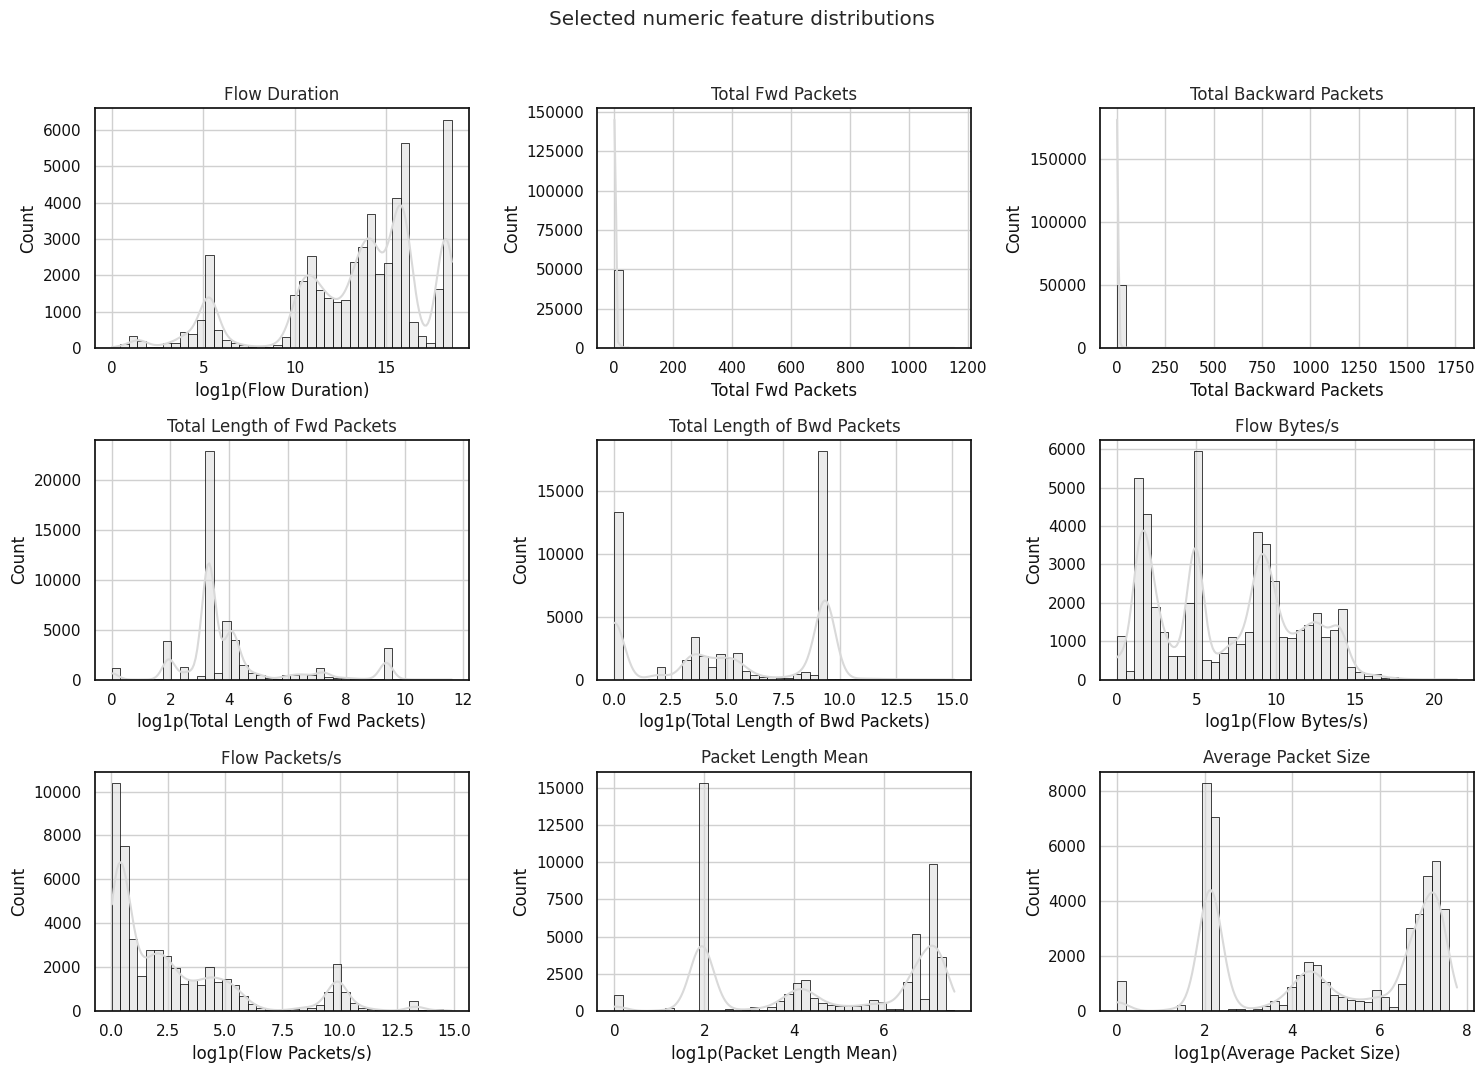

No categorical columns available for count plots.

In [7]:
plot_numeric_distributions(df, [c for c in PREFERRED_NUMERIC if c in numeric_cols][:9], "Selected numeric feature distributions")
plot_categorical_top_counts(df, [c for c in PREFERRED_CATEGORICAL if c in categorical_cols][:6], "Top category counts")

## Target Relationships

/home/durgaumadev/security-for-data-science-lab/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/durgaumadev/security-for-data-science-lab/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,absolute_correlation_with_target_code
Bwd Packet Length Mean,0.6033
Avg Bwd Segment Size,0.6033
Bwd Packet Length Max,0.5773
Bwd Packet Length Std,0.5762
Destination Port,0.5098
URG Flag Count,0.4632
Packet Length Mean,0.4543
Average Packet Size,0.4535
Packet Length Std,0.4437
Min Packet Length,0.4274


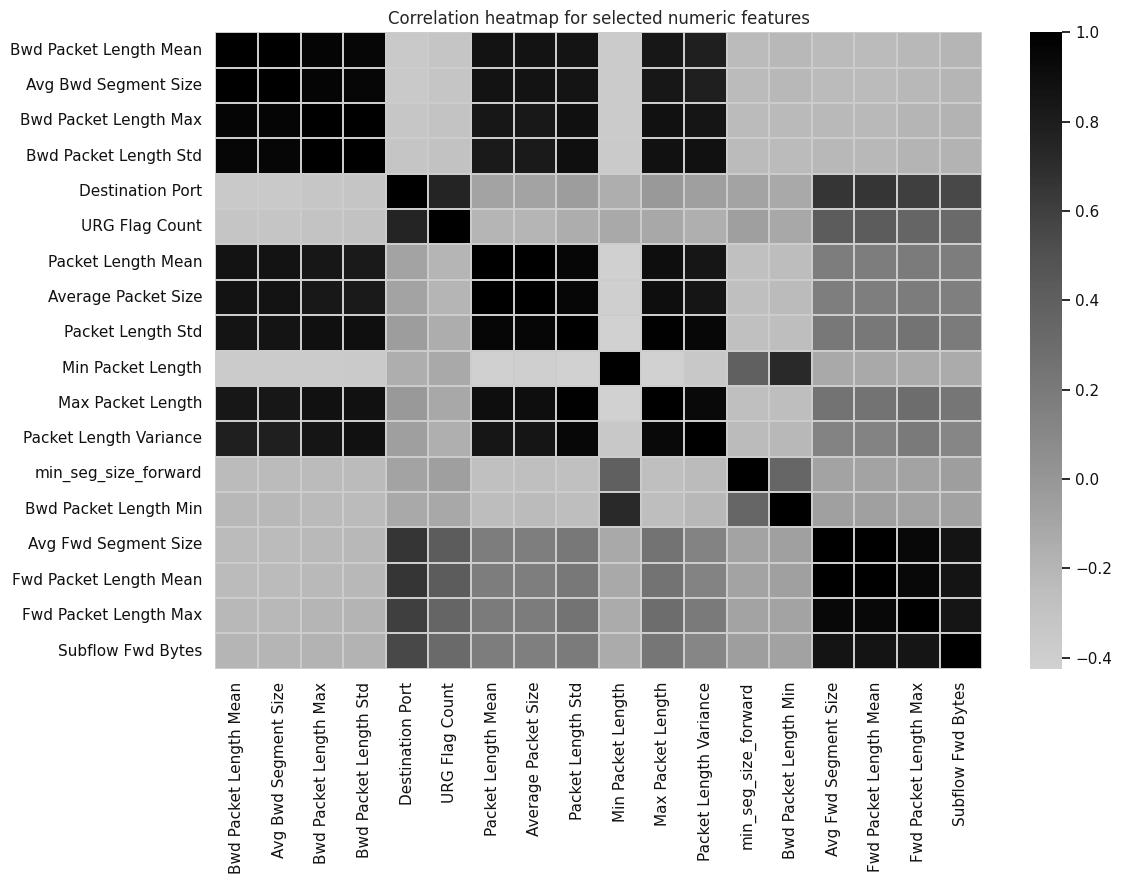

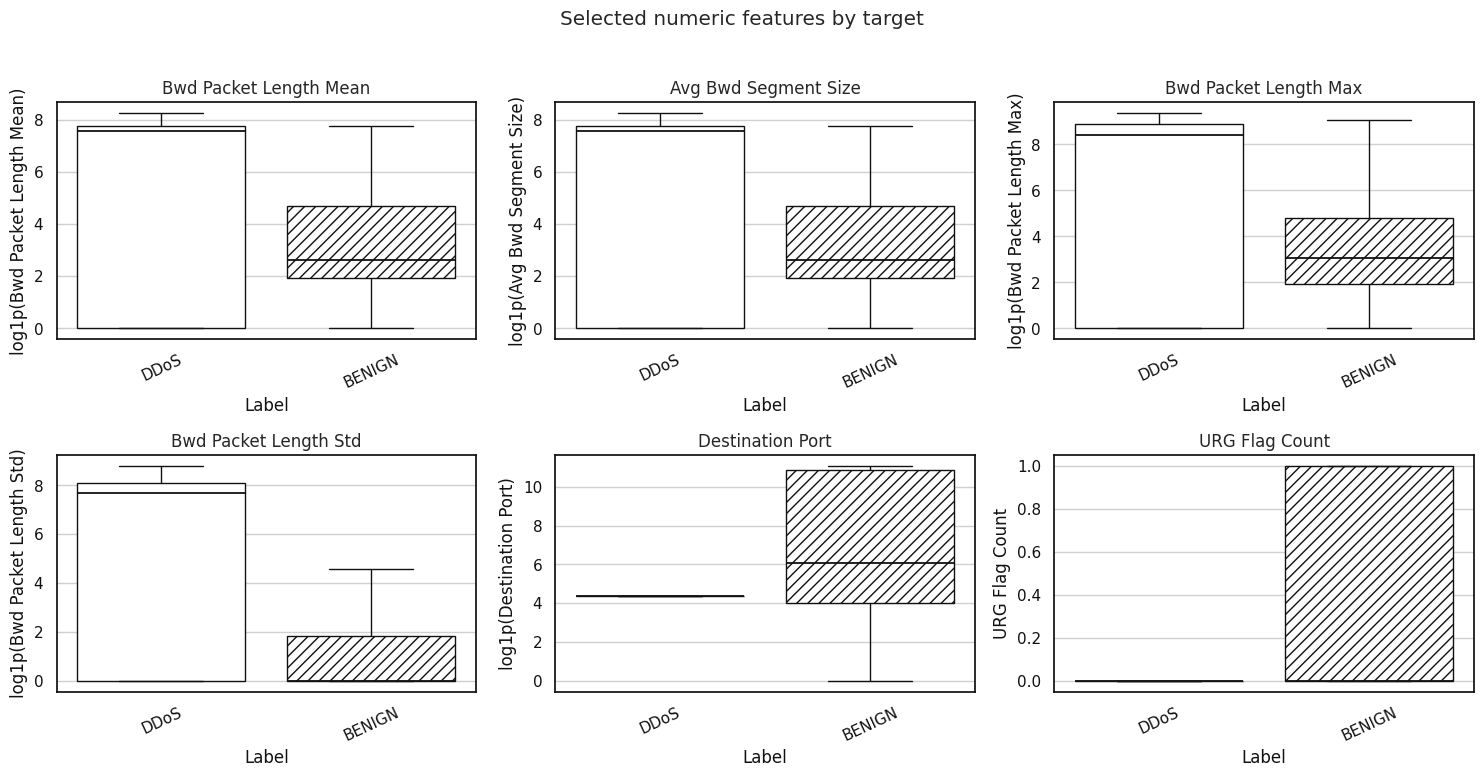

Label,BENIGN,DDoS
Bwd Packet Length Mean,13.0000,"1,934.5000"
Avg Bwd Segment Size,13.0000,"1,934.5000"
Bwd Packet Length Max,20.0000,"5,755.0000"
Bwd Packet Length Std,0.0000,"2,189.7729"
Destination Port,443.0000,80.0000
URG Flag Count,0.0000,0.0000
Packet Length Mean,61.0000,833.5000
Average Packet Size,77.5000,897.6154
Packet Length Std,32.2047,"1,903.9627"
Min Packet Length,6.0000,0.0000


In [8]:

# Target associations and correlation structure
assoc = target_association(df, TARGET_COL, numeric_cols, exclude=EXCLUDE_COLS)
display(assoc.head(20).rename("absolute_correlation_with_target_code").to_frame())

selected_numeric = assoc.head(18).index.tolist()
if len(selected_numeric) < 2:
    selected_numeric = numeric_cols[:18]

plot_correlation_heatmap(df, selected_numeric, "Correlation heatmap for selected numeric features")
plot_numeric_by_target(df, TARGET_COL, selected_numeric[:6], "Selected numeric features by target")

if selected_numeric:
    grouped_median = df.groupby(TARGET_COL)[selected_numeric[:10]].median(numeric_only=True).T
    display(grouped_median)


## Advanced EDA

This section extends the baseline EDA with DDoS-focused model-preparation checks: column-name cleanup, class imbalance, duplicate rows, missing and infinite values, zero-dominant features, outliers, skewness, correlated features, low-variance signals, PCA separation, mutual-information feature ranking, and final preprocessing recommendations.

In [9]:

from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

ADVANCED_SAMPLE_SIZE = 12_000
FEATURE_RANK_SAMPLE_SIZE = 60_000
CORRELATION_THRESHOLD = 0.85
ZERO_DOMINANT_THRESHOLD = 0.90
DOMINANT_VALUE_THRESHOLD = 0.95
LOW_VARIANCE_THRESHOLD = 1e-8

def clean_numeric_frame(data, columns):
    if not columns:
        return pd.DataFrame(index=data.index)
    return data[columns].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

def count_table(data, col):
    counts = data[col].astype("string").fillna("<NA>").value_counts(dropna=False)
    table = counts.rename_axis(col).reset_index(name="count")
    table["percent"] = (table["count"] / len(data) * 100).round(3)
    table["ratio_vs_minority"] = (table["count"] / table["count"].min()).round(3)
    return table

def plot_horizontal_counts(table, label_col, value_col="count", title="Count plot", color="white"):
    if table.empty:
        display(Markdown("No rows available for plotting."))
        return
    plt.figure(figsize=(9, max(3, 0.35 * len(table))))
    ax = sns.barplot(data=table, x=value_col, y=label_col, color="white", edgecolor="#111111")
    apply_bar_hatches(ax)
    plt.title(title)
    plt.xlabel(value_col.replace("_", " ").title())
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

def safe_inf_counts(numeric_data):
    if numeric_data.empty:
        return {"pos_inf": 0, "neg_inf": 0, "total_inf": 0}
    arr = numeric_data.to_numpy(dtype="float64", copy=False)
    pos_inf = int(np.isposinf(arr).sum())
    neg_inf = int(np.isneginf(arr).sum())
    return {"pos_inf": pos_inf, "neg_inf": neg_inf, "total_inf": pos_inf + neg_inf}

def pca_projection(data, numeric_columns, color_col, sample_size, title):
    pca_numeric_cols = [
        col for col in numeric_columns
        if data[col].nunique(dropna=True) > 1 and pd.to_numeric(data[col], errors="coerce").notna().any()
    ]
    if len(pca_numeric_cols) < 2:
        display(Markdown("PCA requires at least two non-constant numeric features."))
        return pd.DataFrame()

    pca_sample = sampled(data[[color_col] + pca_numeric_cols], sample_size)
    X_numeric = clean_numeric_frame(pca_sample, pca_numeric_cols)
    X_imputed = SimpleImputer(strategy="median").fit_transform(X_numeric)
    X_scaled = StandardScaler().fit_transform(X_imputed)
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pcs = pca.fit_transform(X_scaled)
    pca_result = pd.DataFrame({
        "PC1": pcs[:, 0],
        "PC2": pcs[:, 1],
        color_col: pca_sample[color_col].astype("string").fillna("<NA>").to_numpy(),
    })
    explained = pca.explained_variance_ratio_ * 100
    display(pd.DataFrame({
        "component": ["PC1", "PC2"],
        "explained_variance_percent": explained.round(3),
    }))

    scatter_with_markers(
        pca_result,
        "PC1",
        "PC2",
        color_col,
        title,
        xlabel=f"PC1 ({explained[0]:.2f}% variance)",
        ylabel=f"PC2 ({explained[1]:.2f}% variance)",
    )
    return pca_result


## Column Name Cleanup Check

In [10]:

raw_columns = pd.Index(raw_df.columns)
clean_columns = raw_columns.str.strip()
column_cleanup_table = pd.DataFrame({
    "raw_column": raw_columns,
    "clean_column": clean_columns,
    "changed_by_strip": raw_columns != clean_columns,
})

cleanup_summary = pd.DataFrame({
    "metric": ["columns_changed_by_strip", "duplicate_columns_after_strip", "current_duplicate_columns"],
    "value": [
        int(column_cleanup_table["changed_by_strip"].sum()),
        int(clean_columns.duplicated().sum()),
        int(pd.Index(df.columns).duplicated().sum()),
    ],
})
display(cleanup_summary)
display(column_cleanup_table[column_cleanup_table["changed_by_strip"]].head(30))


,metric,value
0,columns_changed_by_strip,65
1,duplicate_columns_after_strip,0
2,current_duplicate_columns,0


,raw_column,clean_column,changed_by_strip
0,Destination Port,Destination Port,True
1,Flow Duration,Flow Duration,True
2,Total Fwd Packets,Total Fwd Packets,True
3,Total Backward Packets,Total Backward Packets,True
5,Total Length of Bwd Packets,Total Length of Bwd Packets,True
6,Fwd Packet Length Max,Fwd Packet Length Max,True
7,Fwd Packet Length Min,Fwd Packet Length Min,True
8,Fwd Packet Length Mean,Fwd Packet Length Mean,True
9,Fwd Packet Length Std,Fwd Packet Length Std,True
11,Bwd Packet Length Min,Bwd Packet Length Min,True


## Class Imbalance Analysis For Label

,Label,count,percent,ratio_vs_minority
0,DDoS,128027,56.7130,1.3100
1,BENIGN,97718,43.2870,1.0000


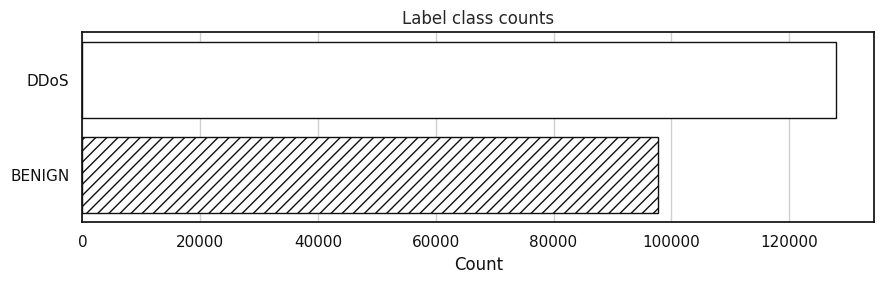

Binary target detected. Majority `DDoS` has 128,027 rows; minority `BENIGN` has 97,718 rows. Majority/minority ratio: 1.310:1.

In [11]:

label_balance = count_table(df, TARGET_COL)
display(label_balance)
plot_horizontal_counts(label_balance, TARGET_COL, "count", "Label class counts", color="white")

if len(label_balance) == 2:
    majority = label_balance.iloc[0]
    minority = label_balance.iloc[-1]
    display(Markdown(
        f"Binary target detected. Majority `{majority[TARGET_COL]}` has {majority['count']:,} rows; "
        f"minority `{minority[TARGET_COL]}` has {minority['count']:,} rows. Majority/minority ratio: "
        f"{majority['ratio_vs_minority']:.3f}:1."
    ))
else:
    display(Markdown(f"`{TARGET_COL}` has {len(label_balance):,} classes."))


## Duplicate Analysis

,metric,value
0,duplicate_rows_keep_first,2633
1,rows_in_duplicate_groups,3940
2,duplicate_groups,1307


,Label,rows_in_duplicate_groups,percent_of_duplicate_rows
0,BENIGN,3920,99.4920
1,DDoS,20,0.5080


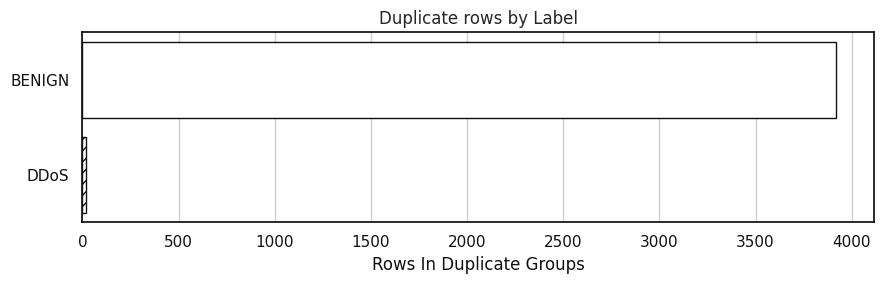

,duplicate_group_size,Label,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s
1190,118,BENIGN,3,2,0,12,0,"4,000,000.0000"
1187,42,BENIGN,1,2,0,12,0,"12,000,000.0000"
1199,32,BENIGN,4,2,0,12,0,"3,000,000.0000"
1204,27,BENIGN,48,2,0,12,0,"250,000.0000"
807,20,BENIGN,247,2,2,64,258,"1,303,643.7250"
1139,18,BENIGN,3,2,0,124,0,"41,300,000.0000"
1207,18,BENIGN,49,2,0,12,0,"244,897.9592"
1142,17,BENIGN,4,2,0,124,0,"31,000,000.0000"
1140,15,BENIGN,3,2,0,124,0,"41,300,000.0000"
845,13,BENIGN,251,2,2,64,258,"1,282,868.5260"


In [12]:

duplicate_mask = df.duplicated(keep=False)
duplicate_rows = df[duplicate_mask].copy()

duplicate_summary = pd.DataFrame({
    "metric": ["duplicate_rows_keep_first", "rows_in_duplicate_groups", "duplicate_groups"],
    "value": [
        int(df.duplicated().sum()),
        int(duplicate_mask.sum()),
        int(df[duplicate_mask].value_counts(dropna=False).shape[0]) if duplicate_mask.any() else 0,
    ],
})
display(duplicate_summary)

if duplicate_mask.any():
    duplicate_by_label = (
        duplicate_rows[TARGET_COL]
        .astype("string")
        .fillna("<NA>")
        .value_counts()
        .rename_axis(TARGET_COL)
        .reset_index(name="rows_in_duplicate_groups")
    )
    duplicate_by_label["percent_of_duplicate_rows"] = (duplicate_by_label["rows_in_duplicate_groups"] / len(duplicate_rows) * 100).round(3)
    display(duplicate_by_label)
    plot_horizontal_counts(duplicate_by_label, TARGET_COL, "rows_in_duplicate_groups", "Duplicate rows by Label", color="white")

    duplicate_group_sizes = (
        df[duplicate_mask]
        .groupby(df.columns.tolist(), dropna=False)
        .size()
        .reset_index(name="duplicate_group_size")
        .sort_values("duplicate_group_size", ascending=False)
    )
    display(duplicate_group_sizes[["duplicate_group_size", TARGET_COL] + [c for c in PREFERRED_NUMERIC if c in duplicate_group_sizes.columns][:6]].head(10))
else:
    display(Markdown("No duplicate rows found."))


## Missing, Inf, And -Inf Handling Analysis

,metric,value
0,raw_positive_inf_values,64
1,raw_negative_inf_values,0
2,raw_total_inf_values,64
3,current_positive_inf_values,0
4,current_negative_inf_values,0
5,current_total_inf_values,0
6,current_missing_cells,68


,dtype,missing_count,missing_percent,unique_values,raw_positive_inf,raw_negative_inf,raw_total_inf
Flow Packets/s,float64,34,0.0150,194094,34,0,34
Flow Bytes/s,float64,34,0.0150,202293,30,0,30
Destination Port,int64,0,0.0000,23950,0,0,0
Flow Duration,int64,0,0.0000,187752,0,0,0
Total Fwd Packets,int64,0,0.0000,297,0,0,0
Total Backward Packets,int64,0,0.0000,367,0,0,0
Total Length of Fwd Packets,int64,0,0.0000,3831,0,0,0
Total Length of Bwd Packets,int64,0,0.0000,6760,0,0,0
Fwd Packet Length Max,int64,0,0.0000,1891,0,0,0
Fwd Packet Length Min,int64,0,0.0000,151,0,0,0


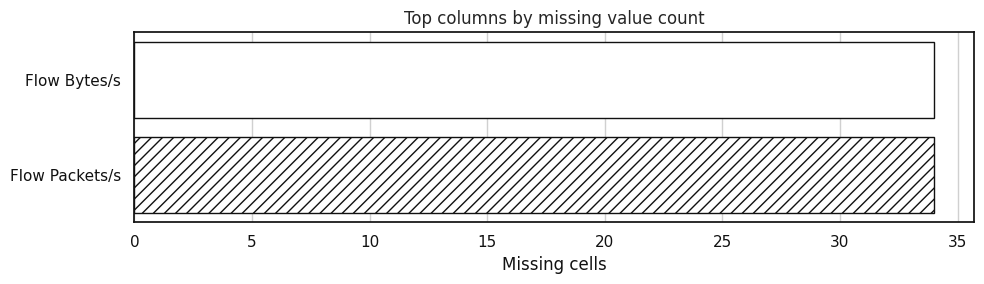

In [13]:

raw_numeric = raw_df.select_dtypes(include=np.number)
raw_inf_counts = safe_inf_counts(raw_numeric)
current_numeric = clean_numeric_frame(df, numeric_cols)
current_inf_counts = safe_inf_counts(df[numeric_cols].select_dtypes(include=np.number))

invalid_summary = pd.DataFrame({
    "metric": [
        "raw_positive_inf_values",
        "raw_negative_inf_values",
        "raw_total_inf_values",
        "current_positive_inf_values",
        "current_negative_inf_values",
        "current_total_inf_values",
        "current_missing_cells",
    ],
    "value": [
        raw_inf_counts["pos_inf"],
        raw_inf_counts["neg_inf"],
        raw_inf_counts["total_inf"],
        current_inf_counts["pos_inf"],
        current_inf_counts["neg_inf"],
        current_inf_counts["total_inf"],
        int(df.isna().sum().sum()),
    ],
})
display(invalid_summary)

raw_inf_by_col = pd.DataFrame(index=raw_numeric.columns.str.strip())
if not raw_numeric.empty:
    raw_arr = raw_numeric.to_numpy(dtype="float64", copy=False)
    raw_inf_by_col["raw_positive_inf"] = np.isposinf(raw_arr).sum(axis=0)
    raw_inf_by_col["raw_negative_inf"] = np.isneginf(raw_arr).sum(axis=0)
    raw_inf_by_col["raw_total_inf"] = raw_inf_by_col["raw_positive_inf"] + raw_inf_by_col["raw_negative_inf"]
else:
    raw_inf_by_col["raw_positive_inf"] = []
    raw_inf_by_col["raw_negative_inf"] = []
    raw_inf_by_col["raw_total_inf"] = []

quality_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df) * 100).round(3),
    "unique_values": df.nunique(dropna=False),
})
quality_table = quality_table.join(raw_inf_by_col, how="left").fillna({
    "raw_positive_inf": 0,
    "raw_negative_inf": 0,
    "raw_total_inf": 0,
})
quality_table[["raw_positive_inf", "raw_negative_inf", "raw_total_inf"]] = quality_table[["raw_positive_inf", "raw_negative_inf", "raw_total_inf"]].astype(int)
quality_table = quality_table.sort_values(["missing_count", "raw_total_inf"], ascending=False)
display(quality_table.head(30))

plot_missing_values(df)


## Zero-Dominant Feature Analysis

,column,zero_count,zero_percent,non_missing_count,unique_values,is_zero_dominant
61,Bwd Avg Bulk Rate,225745,100.0000,225745,1,True
60,Bwd Avg Packets/Bulk,225745,100.0000,225745,1,True
58,Fwd Avg Bulk Rate,225745,100.0000,225745,1,True
31,Bwd PSH Flags,225745,100.0000,225745,1,True
56,Fwd Avg Bytes/Bulk,225745,100.0000,225745,1,True
57,Fwd Avg Packets/Bulk,225745,100.0000,225745,1,True
49,CWE Flag Count,225745,100.0000,225745,1,True
59,Bwd Avg Bytes/Bulk,225745,100.0000,225745,1,True
33,Bwd URG Flags,225745,100.0000,225745,1,True
32,Fwd URG Flags,225745,100.0000,225745,1,True


,column,zero_count,zero_percent,non_missing_count,unique_values,is_zero_dominant
61,Bwd Avg Bulk Rate,225745,100.0000,225745,1,True
60,Bwd Avg Packets/Bulk,225745,100.0000,225745,1,True
58,Fwd Avg Bulk Rate,225745,100.0000,225745,1,True
31,Bwd PSH Flags,225745,100.0000,225745,1,True
56,Fwd Avg Bytes/Bulk,225745,100.0000,225745,1,True
57,Fwd Avg Packets/Bulk,225745,100.0000,225745,1,True
49,CWE Flag Count,225745,100.0000,225745,1,True
59,Bwd Avg Bytes/Bulk,225745,100.0000,225745,1,True
33,Bwd URG Flags,225745,100.0000,225745,1,True
32,Fwd URG Flags,225745,100.0000,225745,1,True


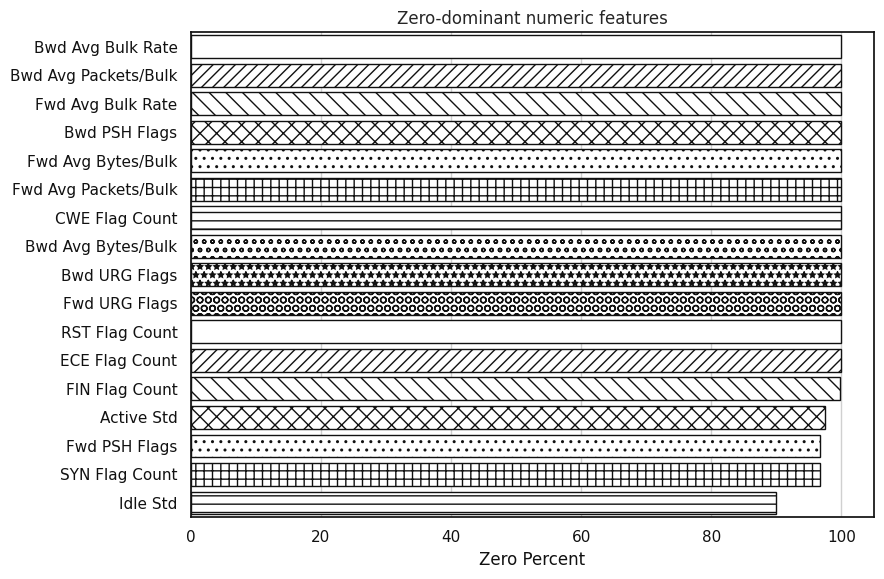

In [14]:

numeric_for_zero = clean_numeric_frame(df, numeric_cols)
zero_counts = numeric_for_zero.eq(0).sum()
zero_dominance_table = pd.DataFrame({
    "column": zero_counts.index,
    "zero_count": zero_counts.astype(int).values,
    "zero_percent": (zero_counts / len(df) * 100).round(3).values,
    "non_missing_count": numeric_for_zero.notna().sum().astype(int).values,
    "unique_values": [df[c].nunique(dropna=False) for c in zero_counts.index],
}).sort_values("zero_percent", ascending=False)
zero_dominance_table["is_zero_dominant"] = zero_dominance_table["zero_percent"] >= ZERO_DOMINANT_THRESHOLD * 100

display(zero_dominance_table.head(30))
zero_dominant_features = zero_dominance_table[zero_dominance_table["is_zero_dominant"]]
display(zero_dominant_features)

if not zero_dominant_features.empty:
    plot_horizontal_counts(zero_dominant_features.head(20), "column", "zero_percent", "Zero-dominant numeric features", color="white")
else:
    display(Markdown(f"No numeric features have at least {ZERO_DOMINANT_THRESHOLD:.0%} zero values."))


## IQR-Based Outlier Count Table

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent,non_null
14,Flow Bytes/s,12.0819,"21,580.2368","21,568.1549","-32,340.1505","53,932.4693",46394,20.5550,225711
70,Active Mean,0.0000,"1,878.0000","1,878.0000","-2,817.0000","4,695.0000",43738,19.3750,225745
72,Active Max,0.0000,"1,878.0000","1,878.0000","-2,817.0000","4,695.0000",43738,19.3750,225745
73,Active Min,0.0000,"1,862.0000","1,862.0000","-2,793.0000","4,655.0000",43648,19.3350,225745
37,Bwd Packets/s,0.0353,21.0247,20.9895,-31.4489,52.5090,40923,18.1280,225745
36,Fwd Packets/s,0.4247,32.8727,32.4481,-48.2474,81.5448,39806,17.6330,225745
15,Flow Packets/s,0.6185,70.3561,69.7376,-103.9880,174.9626,39133,17.3380,225711
63,Subflow Fwd Bytes,26.0000,63.0000,37.0000,-29.5000,118.5000,37478,16.6020,225745
4,Total Length of Fwd Packets,26.0000,63.0000,37.0000,-29.5000,118.5000,37478,16.6020,225745
1,Flow Duration,"71,180.0000","8,805,237.0000","8,734,057.0000","-13,029,905.5000","21,906,322.5000",37465,16.5960,225745


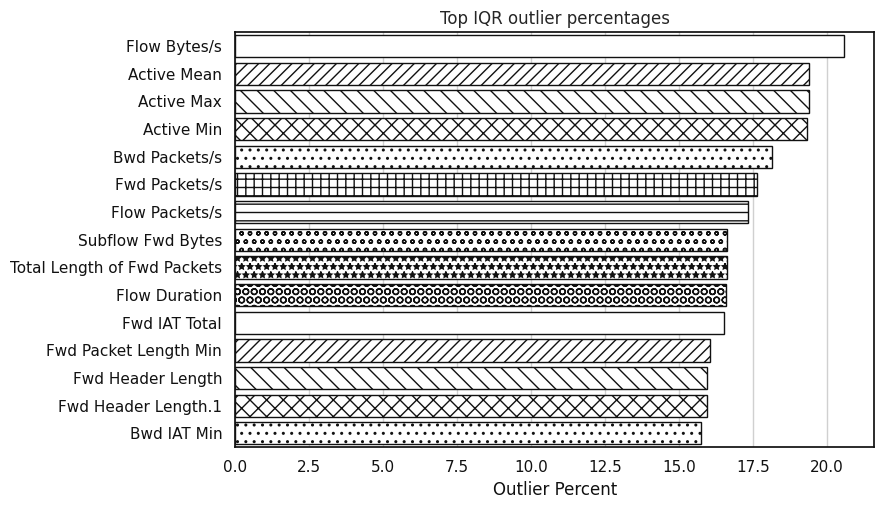

In [15]:

outlier_rows = []
for col in numeric_cols:
    values = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if values.empty:
        continue
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    if np.isclose(iqr, 0):
        outlier_count = 0
    else:
        outlier_count = int(((values < lower) | (values > upper)).sum())
    outlier_rows.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": round(outlier_count / len(values) * 100, 3),
        "non_null": int(values.shape[0]),
    })

iqr_outlier_table = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(iqr_outlier_table.head(30))

plot_iqr = iqr_outlier_table[iqr_outlier_table["outlier_count"] > 0].head(15)
if not plot_iqr.empty:
    plot_horizontal_counts(plot_iqr, "column", "outlier_percent", "Top IQR outlier percentages", color="white")
else:
    display(Markdown("No IQR outliers detected after excluding zero-IQR columns."))


## Skewness Ranking And Log-Transform Suggestions

,skewness,abs_skewness,transform_suggestion
ECE Flag Count,91.4223,91.4223,consider_log1p
RST Flag Count,91.4223,91.4223,consider_log1p
act_data_pkt_fwd,79.2606,79.2606,consider_log1p
Active Std,77.5387,77.5387,consider_log1p
Flow Bytes/s,73.8468,73.8468,consider_robust_or_quantile_transform
Total Length of Bwd Packets,69.5972,69.5972,consider_log1p
Subflow Bwd Bytes,69.5972,69.5972,consider_log1p
Subflow Bwd Packets,66.2118,66.2118,consider_log1p
Total Backward Packets,66.2118,66.2118,consider_log1p
Subflow Fwd Packets,59.6370,59.6370,consider_log1p


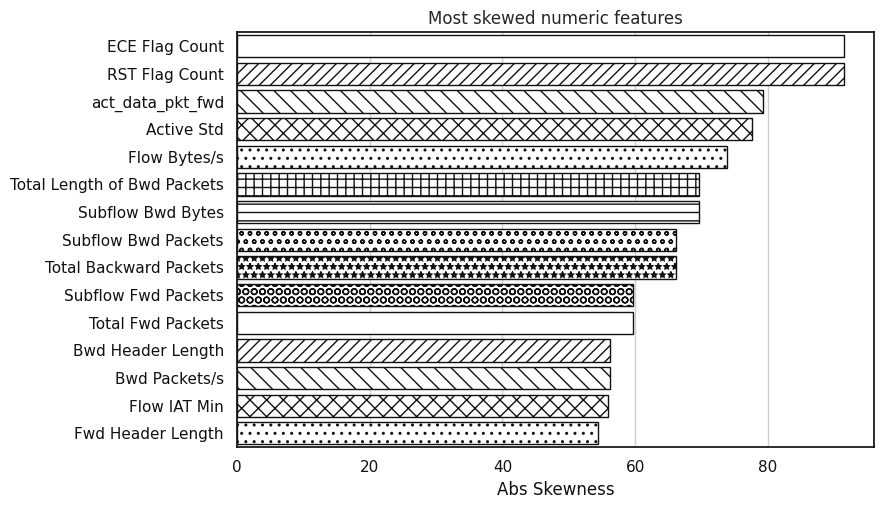

In [16]:

skew_values = clean_numeric_frame(df, numeric_cols).skew(numeric_only=True).dropna()
skewness_table = (
    skew_values.rename("skewness")
    .to_frame()
    .assign(abs_skewness=lambda x: x["skewness"].abs())
    .sort_values("abs_skewness", ascending=False)
)

log_transform_suggestions = []
for col in skewness_table.index:
    values = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if values.empty:
        suggestion = "skip_empty"
    elif values.min() >= 0 and abs(skewness_table.loc[col, "skewness"]) >= 2:
        suggestion = "consider_log1p"
    elif values.min() > 0 and abs(skewness_table.loc[col, "skewness"]) >= 2:
        suggestion = "consider_log"
    elif abs(skewness_table.loc[col, "skewness"]) >= 2:
        suggestion = "consider_robust_or_quantile_transform"
    else:
        suggestion = "no_log_transform_needed"
    log_transform_suggestions.append(suggestion)

skewness_table["transform_suggestion"] = log_transform_suggestions
display(skewness_table.head(30))

plot_skew = skewness_table.head(15).reset_index(names="column")
if not plot_skew.empty:
    plot_horizontal_counts(plot_skew, "column", "abs_skewness", "Most skewed numeric features", color="white")


## High-Correlation Feature Pair Detection

In [17]:

numeric_clean = clean_numeric_frame(df, numeric_cols)
corr_matrix = numeric_clean.corr().abs()
upper_mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
correlated_pairs = (
    corr_matrix.where(upper_mask)
    .stack()
    .rename("absolute_correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
    .sort_values("absolute_correlation", ascending=False)
)
highly_correlated_pairs = correlated_pairs[correlated_pairs["absolute_correlation"] >= CORRELATION_THRESHOLD]
display(highly_correlated_pairs.head(40))
display(Markdown(f"Found {len(highly_correlated_pairs):,} numeric feature pairs with absolute correlation >= {CORRELATION_THRESHOLD:.2f}."))


,feature_1,feature_2,absolute_correlation
677,Fwd Packet Length Mean,Avg Fwd Segment Size,1.0000
3560,RST Flag Count,ECE Flag Count,1.0000
990,Bwd Packet Length Mean,Avg Bwd Segment Size,1.0000
298,Total Backward Packets,Subflow Bwd Packets,1.0000
218,Total Fwd Packets,Subflow Fwd Packets,1.0000
2707,Fwd Header Length,Fwd Header Length.1,1.0000
375,Total Length of Fwd Packets,Subflow Fwd Bytes,1.0000
2384,Fwd PSH Flags,SYN Flag Count,1.0000
455,Total Length of Bwd Packets,Subflow Bwd Bytes,1.0000
3172,Packet Length Mean,Average Packet Size,0.9994


Found 122 numeric feature pairs with absolute correlation >= 0.85.

## Low-Variance Feature Detection

In [18]:

low_variance_rows = []
for col in [c for c in df.columns if c != TARGET_COL]:
    series = df[col]
    value_counts = series.astype("string").fillna("<NA>").value_counts(dropna=False)
    dominant_percent = float(value_counts.iloc[0] / len(series) * 100) if len(value_counts) else np.nan
    unique_values = int(series.nunique(dropna=False))
    row = {
        "column": col,
        "dtype": str(series.dtype),
        "unique_values": unique_values,
        "is_constant": unique_values <= 1,
        "dominant_value": value_counts.index[0] if len(value_counts) else None,
        "dominant_percent": round(dominant_percent, 3),
        "near_constant_by_dominance": dominant_percent >= DOMINANT_VALUE_THRESHOLD * 100 if len(value_counts) else False,
    }
    if pd.api.types.is_numeric_dtype(series):
        values = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
        row["variance"] = float(values.var(skipna=True)) if values.notna().any() else np.nan
        row["zero_or_near_zero_variance"] = bool(pd.notna(row["variance"]) and row["variance"] <= LOW_VARIANCE_THRESHOLD)
    else:
        row["variance"] = np.nan
        row["zero_or_near_zero_variance"] = False
    low_variance_rows.append(row)

low_variance_table = pd.DataFrame(low_variance_rows).sort_values(
    ["is_constant", "zero_or_near_zero_variance", "near_constant_by_dominance", "dominant_percent"],
    ascending=[False, False, False, False],
)
display(low_variance_table.head(35))

low_variance_candidates = low_variance_table[
    low_variance_table["is_constant"] |
    low_variance_table["zero_or_near_zero_variance"] |
    low_variance_table["near_constant_by_dominance"]
]
display(low_variance_candidates)


,column,dtype,unique_values,is_constant,dominant_value,dominant_percent,near_constant_by_dominance,variance,zero_or_near_zero_variance
31,Bwd PSH Flags,int64,1,True,0,100.0000,True,0.0000,True
32,Fwd URG Flags,int64,1,True,0,100.0000,True,0.0000,True
33,Bwd URG Flags,int64,1,True,0,100.0000,True,0.0000,True
49,CWE Flag Count,int64,1,True,0,100.0000,True,0.0000,True
56,Fwd Avg Bytes/Bulk,int64,1,True,0,100.0000,True,0.0000,True
57,Fwd Avg Packets/Bulk,int64,1,True,0,100.0000,True,0.0000,True
58,Fwd Avg Bulk Rate,int64,1,True,0,100.0000,True,0.0000,True
59,Bwd Avg Bytes/Bulk,int64,1,True,0,100.0000,True,0.0000,True
60,Bwd Avg Packets/Bulk,int64,1,True,0,100.0000,True,0.0000,True
61,Bwd Avg Bulk Rate,int64,1,True,0,100.0000,True,0.0000,True


,column,dtype,unique_values,is_constant,dominant_value,dominant_percent,near_constant_by_dominance,variance,zero_or_near_zero_variance
31,Bwd PSH Flags,int64,1,True,0,100.0000,True,0.0000,True
32,Fwd URG Flags,int64,1,True,0,100.0000,True,0.0000,True
33,Bwd URG Flags,int64,1,True,0,100.0000,True,0.0000,True
49,CWE Flag Count,int64,1,True,0,100.0000,True,0.0000,True
56,Fwd Avg Bytes/Bulk,int64,1,True,0,100.0000,True,0.0000,True
57,Fwd Avg Packets/Bulk,int64,1,True,0,100.0000,True,0.0000,True
58,Fwd Avg Bulk Rate,int64,1,True,0,100.0000,True,0.0000,True
59,Bwd Avg Bytes/Bulk,int64,1,True,0,100.0000,True,0.0000,True
60,Bwd Avg Packets/Bulk,int64,1,True,0,100.0000,True,0.0000,True
61,Bwd Avg Bulk Rate,int64,1,True,0,100.0000,True,0.0000,True


## PCA 2D Visualization Colored By Label

,component,explained_variance_percent
0,PC1,21.7110
1,PC2,15.0000


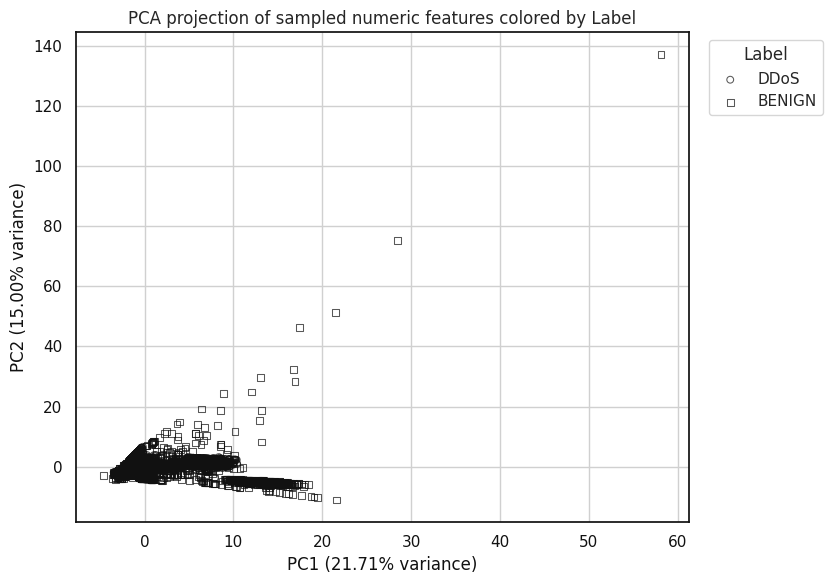

In [19]:

pca_label_result = pca_projection(
    df,
    numeric_cols,
    TARGET_COL,
    ADVANCED_SAMPLE_SIZE,
    "PCA projection of sampled numeric features colored by Label",
)


## Feature Ranking Using Mutual Information

Mutual information was computed on 60,000 sampled rows for speed and stability.

,feature,mutual_information_with_label,feature_type
0,Subflow Fwd Bytes,0.6512,numeric
1,Total Length of Fwd Packets,0.6511,numeric
2,Average Packet Size,0.5626,numeric
3,Total Length of Bwd Packets,0.5417,numeric
4,Subflow Bwd Bytes,0.5412,numeric
5,Bwd Packet Length Mean,0.5407,numeric
6,Fwd Header Length.1,0.5407,numeric
7,Avg Bwd Segment Size,0.5406,numeric
8,Fwd Header Length,0.5405,numeric
9,Destination Port,0.5367,numeric


/tmp/ipykernel_112443/1140206918.py:46: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  ax = sns.barplot(


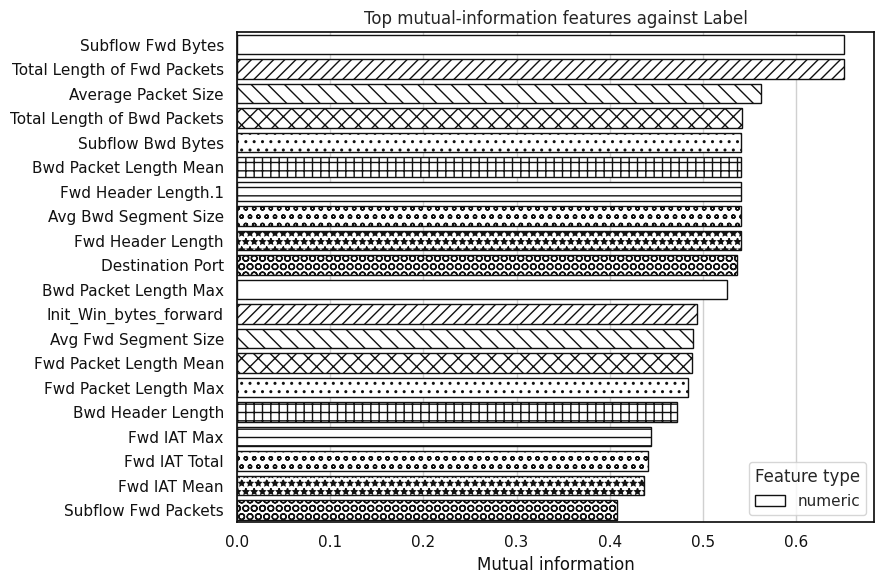

In [20]:

feature_cols = [c for c in df.columns if c != TARGET_COL]
mi_data = sampled(df[[TARGET_COL] + feature_cols], FEATURE_RANK_SAMPLE_SIZE)
y_label = pd.Series(pd.factorize(mi_data[TARGET_COL].astype("string").fillna("<NA>"))[0], index=mi_data.index)

X_parts = []
discrete_features = []
encoded_feature_names = []

for col in feature_cols:
    series = mi_data[col]
    if pd.api.types.is_numeric_dtype(series):
        values = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
        fill_value = values.median() if values.notna().any() else 0
        X_parts.append(values.fillna(fill_value).to_numpy())
        discrete_features.append(False)
    else:
        encoded = pd.factorize(series.astype("string").fillna("<NA>"))[0]
        X_parts.append(encoded)
        discrete_features.append(True)
    encoded_feature_names.append(col)

if not X_parts:
    mi_feature_ranking = pd.DataFrame()
    display(Markdown("No predictors available for mutual information ranking."))
else:
    X_mi = np.column_stack(X_parts)
    mi_scores = mutual_info_classif(
        X_mi,
        y_label,
        discrete_features=np.array(discrete_features, dtype=bool),
        random_state=RANDOM_STATE,
    )
    mi_feature_ranking = (
        pd.DataFrame({
            "feature": encoded_feature_names,
            "mutual_information_with_label": mi_scores,
            "feature_type": ["categorical" if flag else "numeric" for flag in discrete_features],
        })
        .sort_values("mutual_information_with_label", ascending=False)
        .reset_index(drop=True)
    )
    display(Markdown(f"Mutual information was computed on {len(mi_data):,} sampled rows for speed and stability."))
    display(mi_feature_ranking.head(30))

    plt.figure(figsize=(9, 6))
    ax = sns.barplot(
        data=mi_feature_ranking.head(20),
        x="mutual_information_with_label",
        y="feature",
        hue="feature_type",
        dodge=False,
        palette=print_palette(2),
        edgecolor="#111111",
    )
    apply_bar_hatches(ax)
    plt.title("Top mutual-information features against Label")
    plt.xlabel("Mutual information")
    plt.ylabel("")
    plt.legend(title="Feature type")
    plt.tight_layout()
    plt.show()
